# Electricity Theft Detection using Deep Learning

This notebook upgrades the previous ML project into a Deep Learning lab final project.

**Dataset:** `etd.csv`  
**Target:** `FLAG`  
**Problem type:** Binary classification  
**Goal:** Predict whether electricity usage is normal or suspicious.

Deep learning concepts used in this notebook:

- ANN with Batch Normalization, Dropout and L2 regularization
- 1D CNN for daily consumption feature extraction
- Activation functions: ReLU, LeakyReLU, ELU and Tanh
- Optimizers: Adam, SGD, RMSprop and Adagrad
- EarlyStopping logic and ReduceLROnPlateau scheduler
- ML baseline comparison using Logistic Regression and Random Forest
- Gradio web app for prediction

In [34]:
# If any package is missing, run this once:
# !pip install pandas numpy scikit-learn matplotlib seaborn torch gradio joblib

In [35]:
from pathlib import Path
import json
import random
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)

BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
SCREENSHOTS_DIR = BASE_DIR / "screenshots"
for folder in [MODELS_DIR, RESULTS_DIR, SCREENSHOTS_DIR]:
    folder.mkdir(exist_ok=True)

## 1. Load the dataset

The code tries multiple paths, so it works on GitHub, Colab, Jupyter and the Windows path given in the lab prompt.

In [36]:
DATA_PATHS = [
    BASE_DIR / "etd.csv",
    Path("etd.csv"),
    Path("/mnt/data/etd.csv"),
    Path(r"C:\Users\User\OneDrive\Desktop\etd.csv"),
]
DATA_PATH = next((p for p in DATA_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find etd.csv. Put the dataset in this notebook folder or update DATA_PATH.")

print("Dataset path:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset path: c:\Users\User\OneDrive\Desktop\etd.csv
Dataset shape: (25863, 28)


,01/01/2014,01/02/2014,01/03/2014,01/04/2014,01/05/2014,01/06/2014,01/07/2014,01/08/2014,01/09/2014,01/10/2014,...,1/19/2014,1/20/2014,1/21/2014,1/22/2014,1/23/2014,1/24/2014,1/25/2014,1/26/2014,CONS_NO,FLAG
0,2401.0,2500.0,2674.0,2432.00,2231.00,1942.00,2752.00,1244.00,2069.0,2360.0,...,1774.00,2089.0,1300.0,2419.0,2462.0,1177.00,340.00,2272.00,A0E791400CF1C48C43DC26A68227854A,1
1,3318.0,282.0,540.0,5670.00,4854.00,4170.00,4848.00,3546.00,4416.0,3966.0,...,3876.00,3228.0,3054.0,3840.0,1422.0,1956.00,1380.00,96.00,B415F931D3BFB17ACEF48BC648B04FC2,1
2,1020.8,1097.4,1377.4,1408.80,1414.80,1387.40,1444.60,1325.00,1461.6,1253.2,...,1214.60,1285.4,1279.6,1188.6,1362.6,1286.00,1267.60,1444.00,DE8E1EAE4E578C0CEF92D1E23499888F,1
3,0.0,1183.8,1190.4,1183.80,0.00,1154.40,1166.40,1183.80,1169.4,1174.2,...,0.00,1072.8,1090.8,1090.2,1101.0,1079.40,1121.40,1145.40,2952491E940C9040B188B3C9095910D6,0
4,1445.7,1348.2,1281.9,1276.35,1219.95,1289.85,1298.55,1326.15,1410.6,1376.7,...,1331.85,1392.9,1213.2,1463.1,1405.5,1240.05,1190.25,1455.45,DBEED8FD0E7F5E0D1BAF1F86F4983459,1


In [37]:
print("Columns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["FLAG"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Columns:
['01/01/2014', '01/02/2014', '01/03/2014', '01/04/2014', '01/05/2014', '01/06/2014', '01/07/2014', '01/08/2014', '01/09/2014', '01/10/2014', '01/11/2014', '01/12/2014', '1/13/2014', '1/14/2014', '1/15/2014', '1/16/2014', '1/17/2014', '1/18/2014', '1/19/2014', '1/20/2014', '1/21/2014', '1/22/2014', '1/23/2014', '1/24/2014', '1/25/2014', '1/26/2014', 'CONS_NO', 'FLAG']

Target distribution:
FLAG
0    23741
1     2122
Name: count, dtype: int64

Missing values:
1/23/2014    18
1/26/2014    14
1/25/2014    12
1/24/2014    12
1/21/2014     9
1/22/2014     8
1/20/2014     7
1/19/2014     6
1/17/2014     6
1/18/2014     6
dtype: int64


## 2. Basic EDA

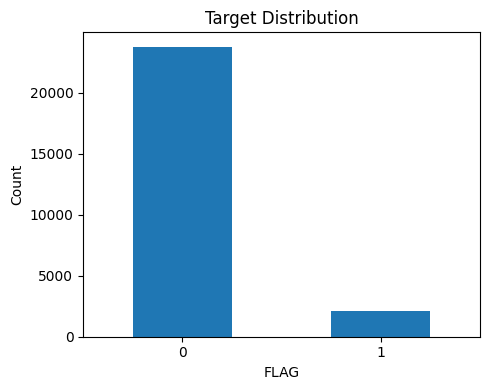

In [38]:
plt.figure(figsize=(5, 4))
df["FLAG"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("FLAG")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

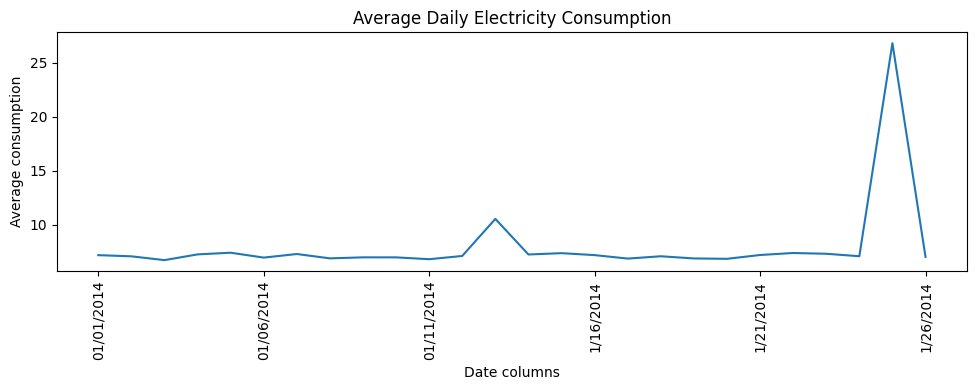

In [39]:
feature_columns = [c for c in df.columns if c not in ["CONS_NO", "FLAG"]]

plt.figure(figsize=(10, 4))
df[feature_columns].mean().plot()
plt.title("Average Daily Electricity Consumption")
plt.xlabel("Date columns")
plt.ylabel("Average consumption")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3. Preprocessing

Steps:

1. Drop `CONS_NO` because it is an ID, not a learning feature.
2. Use the 26 date columns as features.
3. Apply `log1p` to reduce the effect of very large readings.
4. Fill missing values using median imputation.
5. Standardize features using `StandardScaler`.
6. Use stratified train, validation and test split because the target is imbalanced.

In [40]:
X_raw = df[feature_columns].apply(pd.to_numeric, errors="coerce").clip(lower=0)
X = np.log1p(X_raw)
y = df["FLAG"].astype(int).values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=SEED, stratify=y_train_full
)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_train_s = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_s = preprocessor.transform(X_val).astype(np.float32)
X_test_s = preprocessor.transform(X_test).astype(np.float32)

print("Train:", X_train_s.shape)
print("Validation:", X_val_s.shape)
print("Test:", X_test_s.shape)

Train: (18103, 26)
Validation: (3880, 26)
Test: (3880, 26)


## 4. Evaluation helper functions

Because the dataset is imbalanced, F1, Recall and ROC-AUC are more useful than accuracy alone.

In [41]:
def metrics_from_probs(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probs),
    }


def best_threshold(y_true, probs):
    thresholds = np.linspace(0.05, 0.95, 91)
    scores = [f1_score(y_true, probs >= t, zero_division=0) for t in thresholds]
    best_i = int(np.argmax(scores))
    return float(thresholds[best_i]), float(scores[best_i])

## 5. ML baselines

These baselines show what the previous ML approach can do before using deep learning.

In [42]:
logreg = LogisticRegression(max_iter=500, class_weight="balanced", random_state=SEED)
logreg.fit(X_train_s, y_train)
logreg_probs = logreg.predict_proba(X_test_s)[:, 1]

rf = RandomForestClassifier(
    n_estimators=60,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train_s, y_train)
rf_probs = rf.predict_proba(X_test_s)[:, 1]

print("Logistic Regression:", metrics_from_probs(y_test, logreg_probs, 0.50))
print("Random Forest:", metrics_from_probs(y_test, rf_probs, 0.50))

Logistic Regression: {'Accuracy': 0.593298969072165, 'Precision': 0.10575719649561953, 'Recall': 0.5314465408805031, 'F1': 0.17640918580375783, 'ROC_AUC': 0.5983803530629037}
Random Forest: {'Accuracy': 0.9198453608247422, 'Precision': 0.6, 'Recall': 0.0660377358490566, 'F1': 0.11898016997167139, 'ROC_AUC': 0.6131726752336861}


## 6. Deep Learning model classes

The ANN is the main model for tabular data. The 1D CNN treats the 26 daily readings like a short sequence.

In [43]:
class ANNModel(nn.Module):
    def __init__(self, input_dim, activation="relu", dropout=0.30, batch_norm=True):
        super().__init__()
        acts = {
            "relu": nn.ReLU,
            "leaky_relu": lambda: nn.LeakyReLU(0.10),
            "elu": nn.ELU,
            "tanh": nn.Tanh,
        }
        if activation not in acts:
            raise ValueError("activation must be relu, leaky_relu, elu, or tanh")
        def act():
            return acts[activation]()

        layers = [nn.Linear(input_dim, 64)]
        if batch_norm:
            layers.append(nn.BatchNorm1d(64))
        layers += [act(), nn.Dropout(dropout)]

        layers.append(nn.Linear(64, 32))
        if batch_norm:
            layers.append(nn.BatchNorm1d(32))
        layers += [act(), nn.Dropout(dropout)]

        layers += [nn.Linear(32, 16), act(), nn.Linear(16, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class CNN1DModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        return self.head(self.conv(x)).squeeze(1)

## 7. Training function

This training function includes:

- Weighted binary cross entropy for class imbalance
- L2 regularization using `weight_decay`
- ReduceLROnPlateau scheduler
- EarlyStopping logic using validation loss
- In-memory checkpointing of the best model weights

In [44]:
X_train_t = torch.from_numpy(X_train_s)
y_train_t = torch.from_numpy(y_train.astype(np.float32))
X_val_t = torch.from_numpy(X_val_s)
y_val_t = torch.from_numpy(y_val.astype(np.float32))

pos_weight = torch.tensor([np.sum(y_train == 0) / np.sum(y_train == 1)], dtype=torch.float32)


def make_optimizer(model, name="adam", weight_decay=1e-4):
    name = name.lower()
    if name == "adam":
        return torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=0.02, momentum=0.9, weight_decay=weight_decay)
    if name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=0.001, weight_decay=weight_decay)
    if name == "adagrad":
        return torch.optim.Adagrad(model.parameters(), lr=0.01, weight_decay=weight_decay)
    raise ValueError("optimizer must be adam, sgd, rmsprop, or adagrad")


def train_model(model, epochs=15, optimizer_name="adam", patience=4, weight_decay=1e-4, batch_size=1024, verbose=True):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = make_optimizer(model, optimizer_name, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_val_loss = float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": []}
    n = len(X_train_t)

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        order = torch.randperm(n)

        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb = X_train_t[idx]
            yb = y_train_t[idx]

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = float(criterion(model(X_val_t), y_val_t).item())

        train_loss = float(np.mean(train_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        if verbose:
            print(f"Epoch {epoch:02d}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

        if val_loss < best_val_loss - 0.0005:
            best_val_loss = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print("Early stopping triggered")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


def predict_probs(model, X_array):
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X_array.astype(np.float32)))
        return torch.sigmoid(logits).cpu().numpy()

## 8. Train ANN

In [45]:
ann_model = ANNModel(input_dim=X_train_s.shape[1], activation="relu", dropout=0.30, batch_norm=True)
ann_history = train_model(ann_model, epochs=18, patience=4, optimizer_name="adam")

ann_val_probs = predict_probs(ann_model, X_val_s)
ann_threshold, ann_val_f1 = best_threshold(y_val, ann_val_probs)
ann_probs = predict_probs(ann_model, X_test_s)

print("ANN best threshold:", ann_threshold)
print("ANN validation F1:", ann_val_f1)
print("ANN test metrics:", metrics_from_probs(y_test, ann_probs, ann_threshold))

Epoch 01: train_loss=1.2650, val_loss=1.2466
Epoch 02: train_loss=1.2477, val_loss=1.2245
Epoch 03: train_loss=1.2409, val_loss=1.2165
Epoch 04: train_loss=1.2288, val_loss=1.2104
Epoch 05: train_loss=1.2226, val_loss=1.2076
Epoch 06: train_loss=1.2229, val_loss=1.2079
Epoch 07: train_loss=1.2182, val_loss=1.2003
Epoch 08: train_loss=1.2134, val_loss=1.2015
Epoch 09: train_loss=1.2045, val_loss=1.1970
Epoch 10: train_loss=1.2036, val_loss=1.1926
Epoch 11: train_loss=1.2031, val_loss=1.1903
Epoch 12: train_loss=1.1985, val_loss=1.1905
Epoch 13: train_loss=1.1967, val_loss=1.1885
Epoch 14: train_loss=1.1967, val_loss=1.1917
Epoch 15: train_loss=1.1894, val_loss=1.1882
Epoch 16: train_loss=1.1831, val_loss=1.1882
Epoch 17: train_loss=1.1879, val_loss=1.1859
Epoch 18: train_loss=1.1822, val_loss=1.1872
ANN best threshold: 0.57
ANN validation F1: 0.24664224664224665
ANN test metrics: {'Accuracy': 0.8430412371134021, 'Precision': 0.1857451403887689, 'Recall': 0.27044025157232704, 'F1': 0.220

## 9. Train 1D CNN

In [46]:
cnn_model = CNN1DModel(n_features=X_train_s.shape[1])
cnn_history = train_model(cnn_model, epochs=15, patience=4, optimizer_name="adam")

cnn_val_probs = predict_probs(cnn_model, X_val_s)
cnn_threshold, cnn_val_f1 = best_threshold(y_val, cnn_val_probs)
cnn_probs = predict_probs(cnn_model, X_test_s)

print("CNN best threshold:", cnn_threshold)
print("CNN validation F1:", cnn_val_f1)
print("CNN test metrics:", metrics_from_probs(y_test, cnn_probs, cnn_threshold))

Epoch 01: train_loss=1.3200, val_loss=1.2430
Epoch 02: train_loss=1.2669, val_loss=1.2094
Epoch 03: train_loss=1.2488, val_loss=1.1960
Epoch 04: train_loss=1.2234, val_loss=1.1864
Epoch 05: train_loss=1.2267, val_loss=1.1799
Epoch 06: train_loss=1.2302, val_loss=1.1727
Epoch 07: train_loss=1.2299, val_loss=1.1761
Epoch 08: train_loss=1.2153, val_loss=1.1702
Epoch 09: train_loss=1.2165, val_loss=1.1751
Epoch 10: train_loss=1.2104, val_loss=1.1723
Epoch 11: train_loss=1.2156, val_loss=1.1671
Epoch 12: train_loss=1.2097, val_loss=1.1622
Epoch 13: train_loss=1.2081, val_loss=1.1693
Epoch 14: train_loss=1.2050, val_loss=1.1661
Epoch 15: train_loss=1.2101, val_loss=1.1578
CNN best threshold: 0.58
CNN validation F1: 0.2551640340218712
CNN test metrics: {'Accuracy': 0.840979381443299, 'Precision': 0.17987152034261242, 'Recall': 0.2641509433962264, 'F1': 0.2140127388535032, 'ROC_AUC': 0.640540523838279}


## 10. Activation function visualization

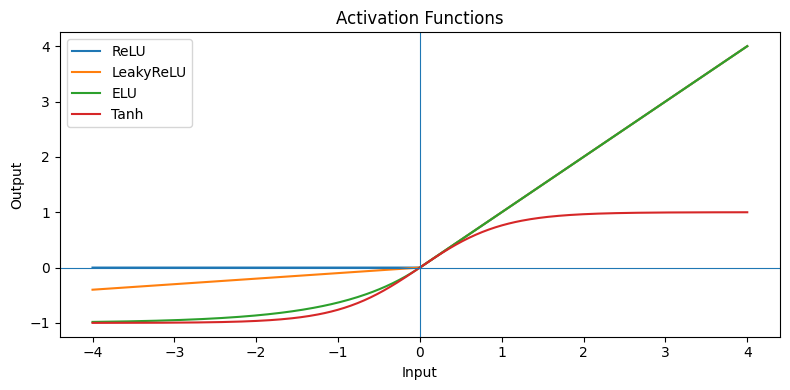

In [47]:
x_vis = np.linspace(-4, 4, 300)
activation_curves = {
    "ReLU": np.maximum(0, x_vis),
    "LeakyReLU": np.where(x_vis > 0, x_vis, 0.1 * x_vis),
    "ELU": np.where(x_vis > 0, x_vis, np.exp(x_vis) - 1),
    "Tanh": np.tanh(x_vis),
}

plt.figure(figsize=(8, 4))
for name, values in activation_curves.items():
    plt.plot(x_vis, values, label=name)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Activation and optimizer comparison

These are short runs so the notebook stays simple and fast.

In [48]:
activation_rows = []
for act in ["relu", "leaky_relu", "elu", "tanh"]:
    temp_model = ANNModel(X_train_s.shape[1], activation=act, dropout=0.25, batch_norm=True)
    hist = train_model(temp_model, epochs=4, patience=2, verbose=False)
    val_probs = predict_probs(temp_model, X_val_s)
    thr, val_f1 = best_threshold(y_val, val_probs)
    activation_rows.append({"Activation": act, "Best_Val_F1": val_f1, "Best_Threshold": thr, "Epochs": len(hist["train_loss"])})

activation_df = pd.DataFrame(activation_rows).round(4)
activation_df

,Activation,Best_Val_F1,Best_Threshold,Epochs
0,relu,0.2304,0.58,4
1,leaky_relu,0.2271,0.61,4
2,elu,0.2082,0.60,4
3,tanh,0.2042,0.63,4


In [49]:
optimizer_rows = []
for opt in ["adam", "sgd", "rmsprop", "adagrad"]:
    temp_model = ANNModel(X_train_s.shape[1], activation="relu", dropout=0.25, batch_norm=True)
    hist = train_model(temp_model, epochs=4, optimizer_name=opt, patience=2, verbose=False)
    val_probs = predict_probs(temp_model, X_val_s)
    thr, val_f1 = best_threshold(y_val, val_probs)
    optimizer_rows.append({"Optimizer": opt, "Best_Val_F1": val_f1, "Best_Threshold": thr, "Epochs": len(hist["train_loss"])})

optimizer_df = pd.DataFrame(optimizer_rows).round(4)
optimizer_df

,Optimizer,Best_Val_F1,Best_Threshold,Epochs
0,adam,0.2246,0.61,4
1,sgd,0.2247,0.61,4
2,rmsprop,0.2316,0.56,4
3,adagrad,0.2231,0.58,4


## 12. Final comparison dashboard

In [50]:
results = [
    {"Model": "Logistic Regression", "Threshold": 0.50, **metrics_from_probs(y_test, logreg_probs, 0.50)},
    {"Model": "Random Forest", "Threshold": 0.50, **metrics_from_probs(y_test, rf_probs, 0.50)},
    {"Model": "ANN", "Threshold": ann_threshold, **metrics_from_probs(y_test, ann_probs, ann_threshold)},
    {"Model": "1D CNN", "Threshold": cnn_threshold, **metrics_from_probs(y_test, cnn_probs, cnn_threshold)},
]
results_df = pd.DataFrame(results).round(4)
results_df

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.50,0.5933,0.1058,0.5314,0.1764,0.5984
1,Random Forest,0.50,0.9198,0.6000,0.0660,0.1190,0.6132
2,ANN,0.57,0.8430,0.1857,0.2704,0.2202,0.6545
3,1D CNN,0.58,0.8410,0.1799,0.2642,0.2140,0.6405


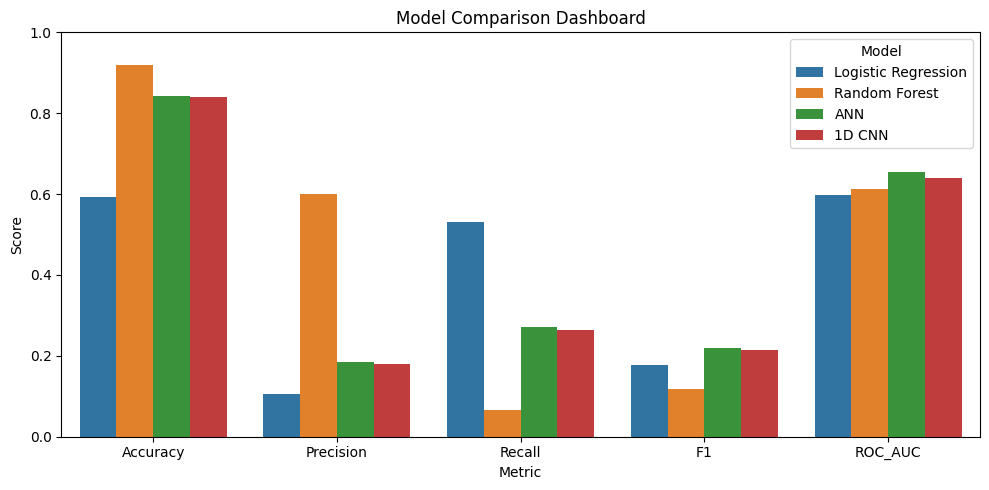

In [51]:
plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Model Comparison Dashboard")
plt.tight_layout()
plt.show()

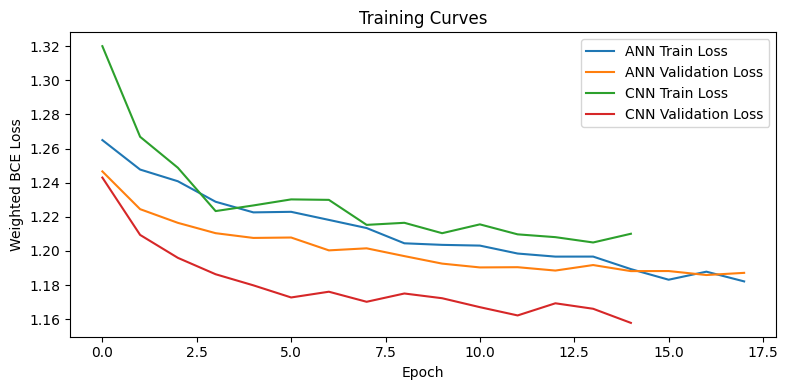

In [52]:
plt.figure(figsize=(8, 4))
plt.plot(ann_history["train_loss"], label="ANN Train Loss")
plt.plot(ann_history["val_loss"], label="ANN Validation Loss")
plt.plot(cnn_history["train_loss"], label="CNN Train Loss")
plt.plot(cnn_history["val_loss"], label="CNN Validation Loss")
plt.title("Training Curves")
plt.xlabel("Epoch")
plt.ylabel("Weighted BCE Loss")
plt.legend()
plt.tight_layout()
plt.show()

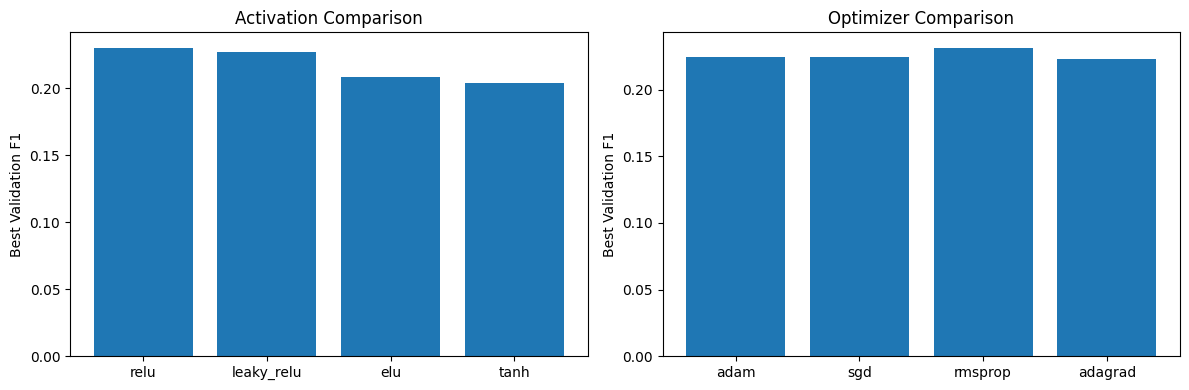

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(activation_df["Activation"], activation_df["Best_Val_F1"])
axes[0].set_title("Activation Comparison")
axes[0].set_ylabel("Best Validation F1")

axes[1].bar(optimizer_df["Optimizer"], optimizer_df["Best_Val_F1"])
axes[1].set_title("Optimizer Comparison")
axes[1].set_ylabel("Best Validation F1")

plt.tight_layout()
plt.show()

## 13. Save models and result files

In [54]:
results_df.to_csv(RESULTS_DIR / "model_results.csv", index=False)
activation_df.to_csv(RESULTS_DIR / "activation_results.csv", index=False)
optimizer_df.to_csv(RESULTS_DIR / "optimizer_results.csv", index=False)

ann_package = {
    "model_state": ann_model.state_dict(),
    "input_dim": X_train_s.shape[1],
    "threshold": ann_threshold,
    "feature_columns": feature_columns,
}
cnn_package = {
    "model_state": cnn_model.state_dict(),
    "input_dim": X_train_s.shape[1],
    "threshold": cnn_threshold,
    "feature_columns": feature_columns,
}

torch.save(ann_package, MODELS_DIR / "etd_ann_model.pt")
torch.save(cnn_package, MODELS_DIR / "etd_cnn_model.pt")
joblib.dump(preprocessor, MODELS_DIR / "etd_preprocessor.pkl")

with open(MODELS_DIR / "feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

print("Saved model files in:", MODELS_DIR)

Saved model files in: c:\Users\User\OneDrive\Desktop\models


## 14. Web app

The project folder includes `app.py`, which is a modern FastAPI + PyTorch web app with a dark dashboard interface.

Run this command in terminal:

```bash
python app.py
```

Then open:

```text
http://127.0.0.1:5000
```

The app loads the saved ANN model, applies the same preprocessing steps and predicts electricity theft risk from the daily meter readings.

In [55]:
# Quick test of the saved app model files after running the save cell.
print("Modern web app is ready: app.py")
print("Run this in terminal: python app.py")
print("Then open: http://127.0.0.1:5000")

Modern web app is ready: app.py
Run this in terminal: python app.py
Then open: http://127.0.0.1:5000


## 15. Project conclusion

The previous ML project has been upgraded into a Deep Learning project. The notebook now includes preprocessing, ML baselines, ANN, 1D CNN, activation comparison, optimizer comparison, regularization and a deployable Gradio app.